#### **RAG Pipeline**

##### **Library & Keys Imports**

In [100]:
import os
from dotenv import load_dotenv
load_dotenv()

True

In [101]:
google_api_key = os.getenv("GEMINI_API_KEY")

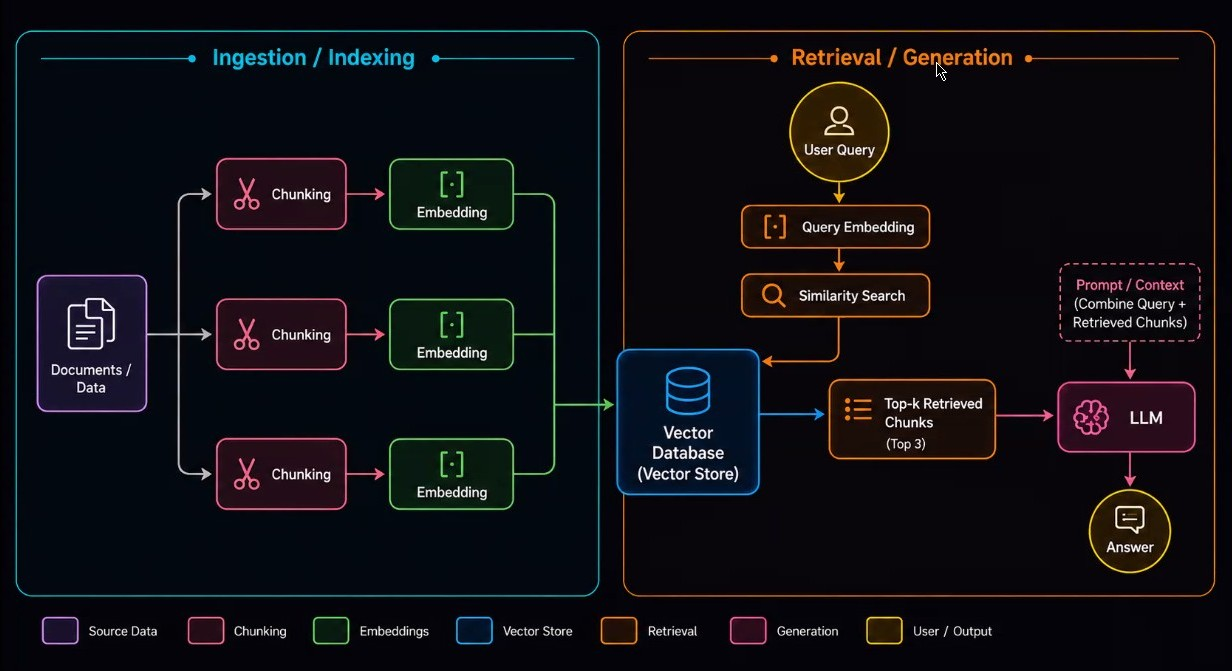

In [102]:
from IPython.display import Image, display
display(Image(filename='C:\Data_science\Modern_route\Research\RAG.jpg'))

##### **1) Data Loader**

In [103]:
from langchain_community.document_loaders import PyPDFLoader

In [104]:
file_path = "C:\Data_science\Modern_route\RAG\RAG_data\deepseek-v4-2026.pdf"
pages = PyPDFLoader(file_path).load()

In [105]:
len(pages)  # Display the number of pages loaded

58

In [106]:
pages[0].metadata

{'producer': 'pikepdf 8.15.1',
 'creator': 'arXiv GenPDF (tex2pdf:a6404ea)',
 'creationdate': '',
 'author': 'DeepSeek-AI; Anyi Xu; Bangcai Lin; Bing Xue; Bingxuan Wang; Bingzheng Xu; Bochao Wu; Bowei Zhang; Chaofan Lin; Chen Dong; Chenchen Ling; Chengda Lu; Chenggang Zhao; Chengqi Deng; Chengyu Hou; Chenhao Xu; Chenze Shao; Chong Ruan; Conner Sun; Damai Dai; Daya Guo; Dejian Yang; Deli Chen; Donghao Li; Dongjie Ji; Erhang Li; Fang Wei; Fangyun Lin; Fangzhou Yuan; Feiyu Xia; Fucong Dai; Guangbo Hao; Guanting Chen; Guoai Cao; Guolai Meng; Guowei Li; Han Yu; Han Zhang; Hanwei Xu; Hao Li; Haofen Liang; Haoling Zhang; Haoming Luo; Haoran Wei; Haotian Yuan; Haowei Zhang; Haowen Luo; Haoyu Chen; Haozhe Ji; Hengqing Zhang; Honghui Ding; Hongxuan Tang; Huanqi Cao; Huazuo Gao; Hui Qu; Hui Zeng; J Yang; JQ Zhu; Jia Luo; Jia Song; Jia Yu; Jialiang Huang; Jialu Cai; Jian Liang; Jiangting Zhou; Jiasheng Ye; Jiashi Li; Jiaxin Xu; Jiewen Hu; Jieyu Yang; Jin Chen; Jin Yan; Jingchang Chen; Jingli Zhou;

In [107]:
pages[0].page_content[:500]  # Display the first 500 characters of the first page

'DeepSeek-V4:\nTowards Highly Efficient Million-Token Context Intelligence\nDeepSeek-AI\nresearch@deepseek.com\nAbstract\nWe present a preview version of DeepSeek-V4 series, including two strong Mixture-of-\nExperts (MoE) language models — DeepSeek-V4-Pro with 1.6T parameters (49B activated) and\nDeepSeek-V4-Flash with 284B parameters (13B activated) — both supporting a context length of\none million tokens. DeepSeek-V4 series incorporate several key upgrades in architecture and op-\ntimization: (1) a hyb'

##### **2) Chunking**

This is not always required. It is very subjective to have this. 

In [108]:
from langchain_text_splitters import RecursiveCharacterTextSplitter

In [109]:
chunker = RecursiveCharacterTextSplitter(chunk_size=1000, chunk_overlap=400)
chunker

In [110]:
chunked_data = chunker.split_documents(pages)
print("Number of chunks created:", len(chunked_data))
chunked_data[:5]

Number of chunks created: 283


[Document(metadata={'producer': 'pikepdf 8.15.1', 'creator': 'arXiv GenPDF (tex2pdf:a6404ea)', 'creationdate': '', 'author': 'DeepSeek-AI; Anyi Xu; Bangcai Lin; Bing Xue; Bingxuan Wang; Bingzheng Xu; Bochao Wu; Bowei Zhang; Chaofan Lin; Chen Dong; Chenchen Ling; Chengda Lu; Chenggang Zhao; Chengqi Deng; Chengyu Hou; Chenhao Xu; Chenze Shao; Chong Ruan; Conner Sun; Damai Dai; Daya Guo; Dejian Yang; Deli Chen; Donghao Li; Dongjie Ji; Erhang Li; Fang Wei; Fangyun Lin; Fangzhou Yuan; Feiyu Xia; Fucong Dai; Guangbo Hao; Guanting Chen; Guoai Cao; Guolai Meng; Guowei Li; Han Yu; Han Zhang; Hanwei Xu; Hao Li; Haofen Liang; Haoling Zhang; Haoming Luo; Haoran Wei; Haotian Yuan; Haowei Zhang; Haowen Luo; Haoyu Chen; Haozhe Ji; Hengqing Zhang; Honghui Ding; Hongxuan Tang; Huanqi Cao; Huazuo Gao; Hui Qu; Hui Zeng; J Yang; JQ Zhu; Jia Luo; Jia Song; Jia Yu; Jialiang Huang; Jialu Cai; Jian Liang; Jiangting Zhou; Jiasheng Ye; Jiashi Li; Jiaxin Xu; Jiewen Hu; Jieyu Yang; Jin Chen; Jin Yan; Jingchang Ch

In [111]:
chunked_data[0].metadata

{'producer': 'pikepdf 8.15.1',
 'creator': 'arXiv GenPDF (tex2pdf:a6404ea)',
 'creationdate': '',
 'author': 'DeepSeek-AI; Anyi Xu; Bangcai Lin; Bing Xue; Bingxuan Wang; Bingzheng Xu; Bochao Wu; Bowei Zhang; Chaofan Lin; Chen Dong; Chenchen Ling; Chengda Lu; Chenggang Zhao; Chengqi Deng; Chengyu Hou; Chenhao Xu; Chenze Shao; Chong Ruan; Conner Sun; Damai Dai; Daya Guo; Dejian Yang; Deli Chen; Donghao Li; Dongjie Ji; Erhang Li; Fang Wei; Fangyun Lin; Fangzhou Yuan; Feiyu Xia; Fucong Dai; Guangbo Hao; Guanting Chen; Guoai Cao; Guolai Meng; Guowei Li; Han Yu; Han Zhang; Hanwei Xu; Hao Li; Haofen Liang; Haoling Zhang; Haoming Luo; Haoran Wei; Haotian Yuan; Haowei Zhang; Haowen Luo; Haoyu Chen; Haozhe Ji; Hengqing Zhang; Honghui Ding; Hongxuan Tang; Huanqi Cao; Huazuo Gao; Hui Qu; Hui Zeng; J Yang; JQ Zhu; Jia Luo; Jia Song; Jia Yu; Jialiang Huang; Jialu Cai; Jian Liang; Jiangting Zhou; Jiasheng Ye; Jiashi Li; Jiaxin Xu; Jiewen Hu; Jieyu Yang; Jin Chen; Jin Yan; Jingchang Chen; Jingli Zhou;

In [112]:
chunked_data[0].page_content[:500]  # Display the first 500 characters of the first chunk

'DeepSeek-V4:\nTowards Highly Efficient Million-Token Context Intelligence\nDeepSeek-AI\nresearch@deepseek.com\nAbstract\nWe present a preview version of DeepSeek-V4 series, including two strong Mixture-of-\nExperts (MoE) language models — DeepSeek-V4-Pro with 1.6T parameters (49B activated) and\nDeepSeek-V4-Flash with 284B parameters (13B activated) — both supporting a context length of\none million tokens. DeepSeek-V4 series incorporate several key upgrades in architecture and op-\ntimization: (1) a hyb'

##### **3) Embeddings model and embedding generation**

In [113]:
from langchain_google_genai import GoogleGenerativeAIEmbeddings

Google has 
- **gemini-embedding-001** (text-only)
- **gemini-embedding-2** (multi-model embeddings model which maps text, images, video, audio, docs)


Langchain is offering gemini-embeddings-2-preview. This with langchain currently accepts only texts, however with GoogleGenAI SDK, it has multi-modal capability. 

This supports flexible output dimensions like 768, 1536, 3072(default)

In [114]:
embeddings = GoogleGenerativeAIEmbeddings(model="gemini-embedding-2", google_api_key=google_api_key, output_dimensionality=768)
vector = embeddings.embed_query("Hello world")
print("Embedding vector length:", len(vector))
print("First 5 dimensions:", vector[:5])  # Display the first 5 dimensions of the embedding

#https://docs.langchain.com/oss/python/integrations/embeddings/google_generative_ai

Embedding vector length: 768
First 5 dimensions: [-0.040384963, 0.018423475, 0.063992426, -0.029232318, -0.02623268]


OpenAI embeddings

In [115]:
from langchain_openai import OpenAIEmbeddings

In [116]:
embeddings = OpenAIEmbeddings(model="text-embedding-3-small", openai_api_key=os.getenv("OPENAI_API_KEY"), dimensions=1024)
vector = embeddings.embed_query("Hello world")
print("Embedding vector length:", len(vector))
print("First 5 dimensions:", vector[:5])  # Display the first 5 dimensions of the embedding

#https://reference.langchain.com/python/langchain-openai/embeddings/base/OpenAIEmbeddings

Embedding vector length: 1024
First 5 dimensions: [-0.0025119781494140625, -0.057037353515625, 0.024383544921875, 0.03643798828125, -0.05267333984375]


##### **4) Vector Store**

Vector store stores embedded data and performs vector search.

One of the most common ways to store and search over unstructured data is to embed it and store the resulting embedding vectors, and then query the store and retrieve the data that are 'most similar' to the embedded query.

In [117]:
import faiss
from langchain_community.vectorstores import FAISS
from langchain_community.docstore.in_memory import InMemoryDocstore

In [118]:
#index = faiss.IndexFlatL2(768)  # 768 is the dimensionality of the embeddings defined above
index = faiss.IndexFlatL2(1024)  # 1024 is the dimensionality of the embeddings defined above

In [119]:
vector_store = FAISS(embedding_function=embeddings, 
                     index=index, 
                     docstore=InMemoryDocstore(), 
                     index_to_docstore_id={}
                     )
vector_store

In [120]:
vector_store.add_documents(chunked_data)

['4ae09d1d-c1d2-4187-a4d3-8d1f700ed005',
 '949e42ca-6645-460a-8714-d6810db50f08',
 'e7eca741-c396-480a-a47f-6ad536b997e6',
 'd9e08c2f-107f-42f7-b08f-1cc574764ad3',
 '38c09220-628c-4f86-b423-b9f0590b57b1',
 '05311eaa-1a95-41d6-9faf-d8cd55ca70af',
 'fdc6e84f-c059-433d-b445-33e7d6d43c30',
 '6531cf13-266e-40a7-854a-9bd75f9fbc30',
 'd92c3efb-da8e-4bdc-92db-d135546f402e',
 '60b32b12-34db-445d-8e5e-3cbe71ab52a1',
 '747eb1de-51ab-4880-89ab-61f48eb053d6',
 '4118930f-bbf6-4c45-86e7-4f9e6ff2dde5',
 '86a2d31f-3e97-47ec-b2b0-17afd1e64e00',
 '185c88c0-3fe5-4428-a903-1afa939822f0',
 '98881525-2b41-4e56-b107-7eaf78f648ec',
 '8c456e4a-b8dd-4b0a-8280-43ea4034bd7f',
 'ba547791-3b63-42b4-a8cf-13d5fe47706f',
 '33a78b08-c269-40c6-8171-81d5d6ebaf88',
 '51fe1b2c-73b5-463d-8d6c-9a33c2f65ca8',
 'c4b8d89a-15aa-47ac-8f6c-f691222e0e37',
 '1efbc9fb-f56e-4d8b-9992-31d272c01a3b',
 'd4611ad3-24c2-43eb-ab9c-0aaf6b267582',
 '83dde0d9-a339-463c-aa8b-0fdd79fd3640',
 'b993ef9b-198f-4cfa-b23f-99611fc53263',
 'cb472be9-f327-

##### **4B) Vector store acting as a retriever**

This first selects how many useful chunks will be sent to the user/LLM as per the user preference

In [121]:
retriever = vector_store.as_retriever(search_kwargs={"k": 10})
# How many chunks to retrieve for each query. Adjust this number based on your needs.

In [122]:
selected_chunks = retriever.invoke("what is this research paper all about?")
selected_chunks

[Document(id='83dde0d9-a339-463c-aa8b-0fdd79fd3640', metadata={'producer': 'pikepdf 8.15.1', 'creator': 'arXiv GenPDF (tex2pdf:a6404ea)', 'creationdate': '', 'author': 'DeepSeek-AI; Anyi Xu; Bangcai Lin; Bing Xue; Bingxuan Wang; Bingzheng Xu; Bochao Wu; Bowei Zhang; Chaofan Lin; Chen Dong; Chenchen Ling; Chengda Lu; Chenggang Zhao; Chengqi Deng; Chengyu Hou; Chenhao Xu; Chenze Shao; Chong Ruan; Conner Sun; Damai Dai; Daya Guo; Dejian Yang; Deli Chen; Donghao Li; Dongjie Ji; Erhang Li; Fang Wei; Fangyun Lin; Fangzhou Yuan; Feiyu Xia; Fucong Dai; Guangbo Hao; Guanting Chen; Guoai Cao; Guolai Meng; Guowei Li; Han Yu; Han Zhang; Hanwei Xu; Hao Li; Haofen Liang; Haoling Zhang; Haoming Luo; Haoran Wei; Haotian Yuan; Haowei Zhang; Haowen Luo; Haoyu Chen; Haozhe Ji; Hengqing Zhang; Honghui Ding; Hongxuan Tang; Huanqi Cao; Huazuo Gao; Hui Qu; Hui Zeng; J Yang; JQ Zhu; Jia Luo; Jia Song; Jia Yu; Jialiang Huang; Jialu Cai; Jian Liang; Jiangting Zhou; Jiasheng Ye; Jiashi Li; Jiaxin Xu; Jiewen Hu; 

In [123]:
for i in range(len(selected_chunks)):
    print(f"Chunk {i+1} (Page {selected_chunks[i].metadata['page']}):")
    print(selected_chunks[i].page_content[:500])  # Display the first 500 characters of each selected chunk
    print("\n---\n")

Chunk 1 (Page 4):
ing (RL) is applied using Group Relative Policy Optimization (GRPO) (DeepSeek-AI, 2025),
which further optimizes the model for domain-aligned behaviors guided by reward models
tailored to specific success criteria. This phase yields a diverse set of specialized experts, each
excelling in its respective field. Finally, to integrate these distinct proficiencies, a single unified
model is trained through on-policy distillation, wherein the unified model acts as the student
learning to optimize the 

---

Chunk 2 (Page 43):
said yes, 39% leaned toward yes, and fewer than 9% said no. Respondents find DeepSeek-V4-Pro
to deliver satisfactory results across most tasks, but note trivial mistakes, misinterpretation of
vague prompts, and occasional over-thinking.
6. Conclusion, Limitations, and Future Directions
In this work, we present a preview version of DeepSeek-V4 series, aiming at next-generation
large language models that break the efficiency barrier of ultra-long-context

##### **5) Prompt Definition**

In [124]:
template = """Answer the question based only on the following context:
{context}


Question: {question}
"""

In [125]:
from langchain_core.prompts import PromptTemplate

In [126]:
prompt = PromptTemplate.from_template(template)
print(prompt)

input_variables=['context', 'question'] input_types={} partial_variables={} template='Answer the question based only on the following context:\n{context}\n\n\nQuestion: {question}\n'


##### **6) Chat Model**

In [127]:
from langchain_google_genai import ChatGoogleGenerativeAI
llm = ChatGoogleGenerativeAI(model="gemini-3.1-flash-lite", google_api_key=google_api_key)


#https://docs.langchain.com/oss/python/integrations/chat/google_generative_ai

In [128]:
resp = llm.invoke("Hello, how are you?")

In [129]:
resp.content[0]["text"]

"I'm doing great, thank you for asking! How are you doing today? Is there anything I can help you with?"

##### **6A) Simple AI Assistant** User query directly to LLM and not part of RAG

In [130]:
while True:
    user_input = input("You: ")
    if user_input.lower() in ["exit", "quit"]:
        print("Exiting the chat. Goodbye!")
        break
    response = llm.invoke(user_input)
    print("AI:", response.content[0]["text"])

Exiting the chat. Goodbye!


##### **Making a RAG chain**

In [131]:
def format_docs(docs):
    return "\n\n".join([doc.page_content for doc in docs])

In [132]:
from langchain_core.output_parsers import StrOutputParser
from langchain_core.runnables import RunnablePassthrough

In [133]:
rag_chain = {"context": retriever | format_docs, "question": RunnablePassthrough()} | prompt | llm | StrOutputParser()

In [135]:
rag_chain.invoke("how many parameters are there in the DeepSeek-V4-Pro model?")

'Based on the provided text, the DeepSeek-V4-Pro model comprises 1.6T total parameters.'

In [136]:
rag_chain.invoke("how many parameters are there in the DeepSeek-V4-Flash model?")

'Based on the provided text, the DeepSeek-V4-Flash model has 284 billion total parameters (with 13 billion activated).'